In [7]:
from mp_api.client import MPRester

# MPRester reads MP_API_KEY from the environment automatically.
# The `with` block opens a managed HTTP session and guarantees it
# closes cleanly even if something errors — that's why we use a
# context manager rather than creating MPRester() loosely.
with MPRester() as mpr:
    # See exactly which fields this endpoint can return:
    print(mpr.materials.insertion_electrodes.available_fields)

['builder_meta', 'battery_type', 'battery_id', 'thermo_type', 'battery_formula', 'working_ion', 'num_steps', 'max_voltage_step', 'last_updated', 'framework', 'framework_formula', 'elements', 'nelements', 'chemsys', 'formula_anonymous', 'warnings', 'formula_charge', 'formula_discharge', 'max_delta_volume', 'average_voltage', 'capacity_grav', 'capacity_vol', 'energy_grav', 'energy_vol', 'fracA_charge', 'fracA_discharge', 'stability_charge', 'stability_discharge', 'id_charge', 'id_discharge', 'host_structure', 'adj_pairs', 'material_ids', 'entries_composition_summary', 'electrode_object']


In [8]:
with MPRester() as mpr:
    sample = mpr.materials.insertion_electrodes.search(
        working_ion="Li",   # start with lithium — the largest, most relevant set
        num_chunks=1,        # limit the download while exploring
        chunk_size=10,       # just 10 records for now
    )

print(f"Got {len(sample)} records")
sample[0]   # inspect one document — look at its attributes

Retrieving InsertionElectrodeDoc documents:   0%|          | 0/10 [00:00<?, ?it/s]

Got 10 records


MPDataDoc<InsertionElectrodeDoc>(
adj_pairs=[InsertionVoltagePairDoc(formula_charge='Ag', formula_discharge='Li3Ag', max_delta_volume=2.736089112284999, average_voltage=0.21056543666666602, capacity_grav=624.785870642994, capacity_vol=1984.8162285987214, energy_grav=131.55830967510573, energy_vol=417.9336958779768, fracA_charge=0.0, fracA_discharge=0.75, stability_charge=0.0036091633333330004, stability_discharge=0.0, id_charge=MPID(mp-124), id_discharge=MPID(mp-865875))],
max_delta_volume=2.736089112284999,
host_structure=Structure Summary
Lattice
    abc : 2.941951704252128 2.941951704252128 2.941951704252128
 angles : 60.00000000000001 60.00000000000001 60.00000000000001
 volume : 18.004937538589626
      A : 0.0 2.080274 2.080274
      B : 2.080274 0.0 2.080274
      C : 2.080274 2.080274 0.0
    pbc : True True True
PeriodicSite: Ag (0.0, 0.0, 0.0) [0.0, 0.0, 0.0],
material_ids=[MPID(mp-124), MPID(mp-865875)],
formula_charge='Ag',
max_voltage_step=0.0,
id_discharge=MPID(mp-865875)

In [9]:
FIELDS = [
    # target
    "average_voltage",
    # composition / identity
    "battery_formula", "framework_formula",
    "formula_charge", "formula_discharge",
    "working_ion", "elements", "nelements", "chemsys",
    # performance
    "capacity_grav", "capacity_vol",
    "energy_grav", "energy_vol",
    "max_delta_volume", "num_steps",
    # stability
    "stability_charge", "stability_discharge",
    # identifiers + data quality
    "battery_id", "id_charge", "id_discharge", "warnings",
]

with MPRester() as mpr:
    docs = mpr.materials.insertion_electrodes.search(
        working_ion="Li",
        fields=FIELDS,
    )

print(f"Retrieved {len(docs)} Li insertion electrodes")

Retrieving InsertionElectrodeDoc documents:   0%|          | 0/2774 [00:00<?, ?it/s]

Retrieved 2774 Li insertion electrodes


In [10]:
import pandas as pd

for doc in docs:
    rows.append({
        "battery_id": doc.battery_id,
        "average_voltage": doc.average_voltage,
        "battery_formula": doc.battery_formula,
        "framework_formula": doc.framework_formula,
        "formula_charge": doc.formula_charge,
        "formula_discharge": doc.formula_discharge,
        "working_ion": str(doc.working_ion),           # Element -> "Li"
        "elements": [str(e) for e in doc.elements],    # [Element] -> ["Ce", ...]
        "nelements": doc.nelements,
        "chemsys": doc.chemsys,
        "capacity_grav": doc.capacity_grav,
        "capacity_vol": doc.capacity_vol,
        "energy_grav": doc.energy_grav,
        "energy_vol": doc.energy_vol,
        "max_delta_volume": doc.max_delta_volume,
        "num_steps": doc.num_steps,
        "stability_charge": doc.stability_charge,
        "stability_discharge": doc.stability_discharge,
        "id_charge": str(doc.id_charge),
        "id_discharge": str(doc.id_discharge),
        "n_warnings": len(doc.warnings) if doc.warnings else 0,
        "warnings": "; ".join(doc.warnings) if doc.warnings else "",
    })

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(2774, 22)


,battery_id,average_voltage,battery_formula,framework_formula,formula_charge,formula_discharge,working_ion,elements,nelements,chemsys,...,energy_grav,energy_vol,max_delta_volume,num_steps,stability_charge,stability_discharge,id_charge,id_discharge,n_warnings,warnings
0,mp-124_Li,0.210565,Li0-3Ag,Ag,Ag,Li3Ag,Li,[Ag],1,Ag,...,131.558310,417.933696,2.736089,1,0.003609,0.000000,mp-124,mp-865875,1,More than one working ion per transition metal
1,mp-2074_Li,1.015953,Li0-3Sb,Sb,Sb,Li3Sb,Li,[Sb],1,Sb,...,572.909146,1920.448911,1.569237,1,0.328351,0.000000,mp-10630,mp-2074,1,Transition metal not found
2,mp-22902_Li,0.796796,Li0-1Bi,Bi,Bi,LiBi,Li,[Bi],1,Bi,...,98.903144,735.871648,0.368255,1,0.049545,0.000000,mp-567597,mp-22902,1,Transition metal not found
3,mp-28_Li,-0.444846,Li0-3Ce,Ce,Ce,Li3Ce,Li,[Ce],1,Ce,...,-222.242937,-576.149771,2.951183,1,0.000000,0.333634,mp-567332,mp-1185231,1,Transition metal not found
4,mp-45_Li,-0.064931,Li0-3Ca,Ca,Ca,Li3Ca,Li,[Ca],1,Ca,...,-85.724587,-82.574983,1.513956,1,0.000000,0.057445,mp-45,mp-975929,1,Transition metal not found


count    2774.000000
mean        3.418654
std         1.532215
min        -7.754751
25%         2.793356
50%         3.537107
75%         4.225228
max        33.065771
Name: average_voltage, dtype: float64

Negative voltage entries: 72
Entries with warnings:    976


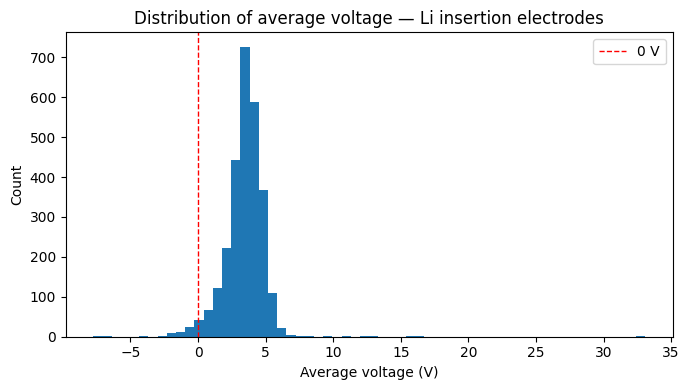

In [13]:
import matplotlib.pyplot as plt

# Basic statistics of the target
print(df["average_voltage"].describe())

# How many physically questionable entries?
n_negative = (df["average_voltage"] < 0).sum()
n_warned = (df["n_warnings"] > 0).sum()
print(f"\nNegative voltage entries: {n_negative}")
print(f"Entries with warnings:    {n_warned}")

# Look at the distribution
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["average_voltage"], bins=60)
ax.axvline(0, color="red", linestyle="--", linewidth=1, label="0 V")
ax.set_xlabel("Average voltage (V)")
ax.set_ylabel("Count")
ax.set_title("Distribution of average voltage — Li insertion electrodes")
ax.legend()
fig.savefig("../blog/Distribution_of_Average_Voltage.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [14]:
# What do the warnings actually say, and how common is each?
from collections import Counter

warning_counts = Counter()
for w in df["warnings"]:
    if w:
        for part in w.split("; "):
            warning_counts[part] += 1
for msg, n in warning_counts.most_common():
    print(f"{n:5d}  {msg}")

# Of the unphysical entries, how many are also warned?
unphysical = (df["average_voltage"] <= 0) | (df["average_voltage"] > 5.5)
print(f"\nUnphysical by voltage (<=0 or >5.5 V): {unphysical.sum()}")
print(f"Of those, also warned: {(unphysical & (df['n_warnings'] > 0)).sum()}")

# Voltage stats for warned vs. unwarned — are warned entries systematically worse?
print("\nWarned entries voltage:")
print(df.loc[df['n_warnings'] > 0, 'average_voltage'].describe())
print("\nUnwarned entries voltage:")
print(df.loc[df['n_warnings'] == 0, 'average_voltage'].describe())

  823  More than one working ion per transition metal
  153  Transition metal not found

Unphysical by voltage (<=0 or >5.5 V): 140
Of those, also warned: 48

Warned entries voltage:
count    976.000000
mean       3.510726
std        1.665346
min       -4.121741
25%        2.861690
50%        3.698479
75%        4.353366
max       33.065771
Name: average_voltage, dtype: float64

Unwarned entries voltage:
count    1798.000000
mean        3.368675
std         1.452899
min        -7.754751
25%         2.732789
50%         3.480053
75%         4.132993
max        16.123656
Name: average_voltage, dtype: float64


In [15]:
# Physical bounds for a viable Li insertion cathode:
#   voltage must be positive (a non-positive insertion voltage means the
#   lithiated phase is not a viable cathode), and below ~5.5 V (real Li
#   cathodes do not exceed this; values up to 33 V are DFT/parsing artifacts).
V_MIN, V_MAX = 0.0, 5.5

mask = (df["average_voltage"] > V_MIN) & (df["average_voltage"] <= V_MAX)

df_clean = df[mask].copy().reset_index(drop=True)

n_removed = len(df) - len(df_clean)
print(f"Removed {n_removed} entries "
      f"({n_removed/len(df)*100:.1f}%) outside [{V_MIN}, {V_MAX}] V")
print(f"Clean dataset: {len(df_clean)} entries")
print(df_clean["average_voltage"].describe())

Removed 140 entries (5.0%) outside [0.0, 5.5] V
Clean dataset: 2634 entries
count    2634.000000
mean        3.443300
std         1.073822
min         0.018507
25%         2.841791
50%         3.541396
75%         4.168261
max         5.499463
Name: average_voltage, dtype: float64


In [16]:
from pathlib import Path

# data/ is gitignored — artifacts live locally, not in the repo
out_dir = Path("../data")
out_dir.mkdir(exist_ok=True)
out_path = out_dir / "li_electrodes_clean.parquet"

df_clean.to_parquet(out_path, index=False)
print(f"Saved {len(df_clean)} rows to {out_path.resolve()}")

# Verify it round-trips correctly
check = pd.read_parquet(out_path)
print(f"Read back {len(check)} rows, {len(check.columns)} columns")

Saved 2634 rows to /home/ameeya/workspace/materials-ml-project/data/li_electrodes_clean.parquet
Read back 2634 rows, 22 columns


In [17]:
from pathlib import Path

raw_dir = Path("../data/raw")
proc_dir = Path("../data/processed")
raw_dir.mkdir(parents=True, exist_ok=True)
proc_dir.mkdir(parents=True, exist_ok=True)

# Raw: the flattened-but-uncleaned data
df.to_csv(raw_dir / "li_electrodes_raw.csv", index=False)
df.to_parquet(raw_dir / "li_electrodes_raw.parquet", index=False)

# Processed: after physics-based cleaning
df_clean.to_csv(proc_dir / "li_electrodes_clean.csv", index=False)
df_clean.to_parquet(proc_dir / "li_electrodes_clean.parquet", index=False)

print("Saved raw and processed data (CSV + Parquet)")

Saved raw and processed data (CSV + Parquet)
